# Vectors and Matrices

In [2]:
# The standard stack:
import numpy as np # Linear algebra and random numbers
import matplotlib.pyplot as plt # Plotting
import pandas as pd # Data handling
import seaborn as sns # Statistical data visualization

## Introduction

- The dataframes we looked at last time were:
    - Variables: Columns of values about the same features of an instance
    - Observations: Rows of values about the same instance 

- A **vector** is an indexed list of $n$ numbers, on which we can do mathematical operations
- We often represent phenomena as indexed lists of numbers:
    - Health outcomes for patients in a clinical trial
    - The sequence of values recorded for an experiment (a particle's position in space, gravity, the speed of light)
    - A sequence of stock prices
- A **matrix** is a set of $\ell$ vectors of length $n$ stacked row-wise or column-wise
- A **tensor** is a **multi-dimensional array** where you index slices of matrices

## Vectors
- In a dataframe, observations are rows and variables are columns: We need notation to track these concepts
- A $1\times m$ row vector is
$$
x = [x_1, x_2, x_3, ..., x_{m}]
$$
- An $n\times 1$ column vector is
$$
y = \left[ \begin{array}{c} y_1 \\ y_2 \\ \vdots \\ y_n \end{array} \right]
$$

In [3]:
df = pd.read_csv('cville_cars.csv')
df.head()

,Unnamed: 0,title,price,year,link,brand,age,log_price,log_age,title.1,year_post,condition,cylinders,drivetrain,fuel,miles,color,transmission,bodytype,text
0,0,2005 hyundai elantra,1200,2005.0,https://charlottesville.craigslist.org/cto/d/a...,missing,20.0,7.090077,2.995732,title,2005,fair,4 cylinders,fwd,gas,232450,silver,manual,sedan,‘05 Elantra runs good but did not pass inspect...
1,1,2007 f250 king ranch,17500,2007.0,https://charlottesville.craigslist.org/cto/d/w...,missing,18.0,9.769956,2.890372,title,2007,good,8 cylinders,4wd,diesel,148086,missing,automatic,pickup,"6.0 diesel, bulletproofed, just replaced trans..."
2,2,1997 dodge 2500 4x4 cummins,9500,1997.0,https://charlottesville.craigslist.org/cto/d/l...,dodge,28.0,9.159047,3.332205,title,1997,fair,6 cylinders,4wd,diesel,179000,red,automatic,truck,1997 Dodge 4x4 Cummins. Adult owned and driven...
3,3,1999 honda civic 4 cyl manual transmission,1000,1999.0,https://charlottesville.craigslist.org/cto/d/c...,honda,26.0,6.907755,3.258097,title,1999,salvage,4 cylinders,rwd,gas,195338,silver,manual,sedan,"Vehicle does start and run, it has a manual tr..."
4,4,"1998 gmc sierra 1500 sl truck auto rwd <103,00...",6250,1998.0,https://charlottesville.craigslist.org/cto/d/l...,gmc,27.0,8.740337,3.295837,title,1998,good,8 cylinders,rwd,gas,102483,missing,automatic,truck,"1998 GMC Sierra 1500 SL Truck, Auto 2WD/RWD, V..."


[Text(0.5, 1.0, 'Visualizing 2-Vectors')]

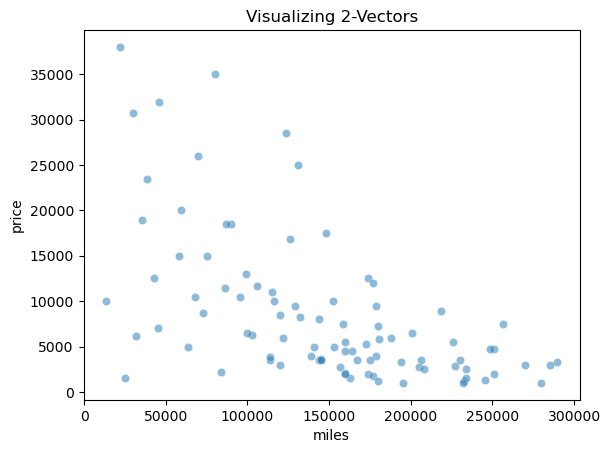

In [4]:
sns.scatterplot(x='miles',
                y='price',
                data=df,
                alpha=.5).set(title='Visualizing 2-Vectors')

[Text(0.5, 1.0, 'Visualizing 3-Vectors')]

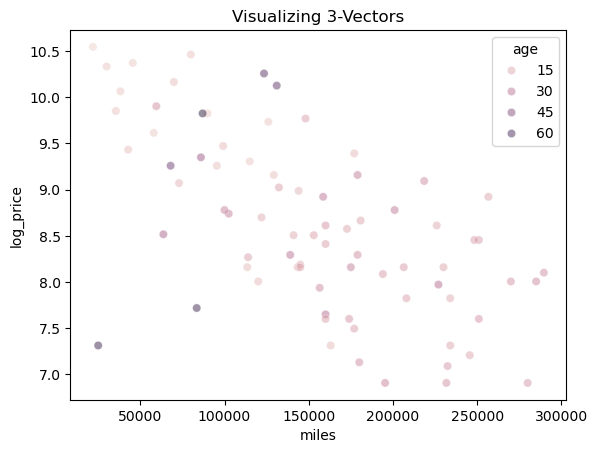

In [5]:
sns.scatterplot(x='miles',
                y='log_price',
                hue = 'age',
                data=df,
                alpha=.5).set(title='Visualizing 3-Vectors')

In [6]:
df = pd.read_csv('CardiacPatientData.csv')
df.head()

,ID,SBP,DBP,HR,RR,BT,SpO2,Age,Gender,GCS,Na,K,Cl,Urea,Ceratinine,Alcoholic,Smoke,FHCD,TriageScore,Outcome
0,1,163,95,90,18,98,98,66,1,15,139.0,4.0,105.0,41.0,91.0,1.0,1.0,0.0,3.0,1
1,1,134,85,85,15,98,98,66,1,15,139.0,4.0,105.0,41.0,91.0,1.0,1.0,0.0,3.0,1
2,1,121,77,80,19,98,98,66,1,15,139.0,4.0,105.0,41.0,91.0,1.0,1.0,0.0,3.0,1
3,1,103,78,70,16,98,98,66,1,15,139.0,4.0,105.0,41.0,91.0,1.0,1.0,0.0,3.0,1
4,1,96,70,59,13,98,98,66,1,15,139.0,4.0,105.0,41.0,91.0,1.0,1.0,0.0,3.0,1


[Text(0.5, 1.0, 'Each Point is a 3-Vector')]

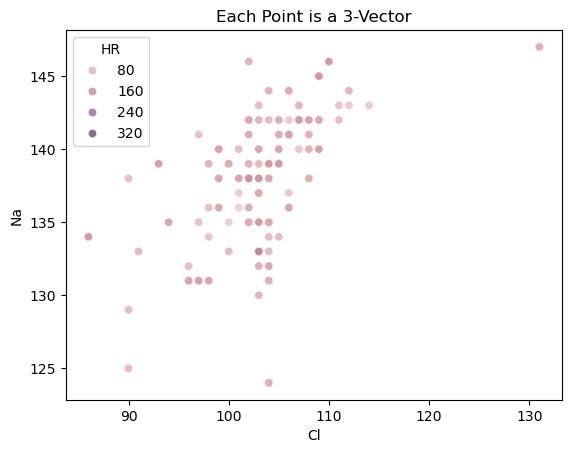

In [7]:
sns.scatterplot(x='Cl',
                y='Na',
                hue = 'HR',
                data=df,
                alpha = .7).set(title='Each Point is a 3-Vector')

## Transpose
- When we take the **transpose** of a vector, we flip it from row to column:
$$
x^{\top} = \left[ \begin{array}{c} x_1 \\ x_2 \\ \vdots \\ x_{m} \end{array} \right]
\quad \text{ and } \quad
y^{\top} = [y_1, y_2, ..., y_{n}]
$$
- As Data Scientists, "row" means observation and "column" means variable

## NumPy
- Vanilla Python doesn't have a vector class by default
- To extend Python to do vector operations, we use the `numpy` package, which provides standard linear algebra tools for data science and machine learning
- If you don't have numpy, you can `pip install numpy` and then `import numpy as np`
- To define a vector, use `x = np.array(vals)` where `vals` is any list of numeric values

## Indexing

- Most programming languages, including Python, however, start indexing from 0 and end at $m-1$ or $n-1$:
$$
x = [x_0, x_1, x_2, ..., x_{m-1}]
$$
and column vectors as 
$$
y = \left[ \begin{array}{c} y_0 \\ y_1 \\ \vdots \\ y_{n-1} \end{array} \right]
$$
- Indexing starts from 0: `x[0]` is the first value in `x`, `x[1]` is the second, and so on
- Notice that `range(n)` yields $0, 1, ..., n-1$

In [8]:
x = np.array([-1, 2, 3, 0])
print(f'The vector x: \n {x}')
print(f'x\'s shape: {x.shape}')

The vector x: 
 [-1  2  3  0]
x's shape: (4,)


## Reshaping
- Numpy pretends to think of all vectors as having a single dimension... and then sometimes demands you **reshape** them explicitly:
    - To row: `x[None,:]` or `x.reshape(1,-1)`
    - To column: `x[:,None]` or `x.reshape(-1,1)`

In [9]:
x_col = x.reshape(-1,1)
print(f'x as a column vector:\n{x_col}')
print(f'x_col\'s shape: {x_col.shape}')
x_col = x[:,None]
print(f'x as a column vector:\n{x_col}')
print(f'x_col\'s shape: {x_col.shape}')
print('\n')
x_row = x.reshape(1,-1)
print(f'x as a row vector:\n{x_row}')
print(f'x_row\'s shape: {x_row.shape}')
x_row = x[None,:]
print(f'x as a row vector:\n{x_row}')
print(f'x_row\'s shape: {x_row.shape}')

x as a column vector:
[[-1]
 [ 2]
 [ 3]
 [ 0]]
x_col's shape: (4, 1)
x as a column vector:
[[-1]
 [ 2]
 [ 3]
 [ 0]]
x_col's shape: (4, 1)


x as a row vector:
[[-1  2  3  0]]
x_row's shape: (1, 4)
x as a row vector:
[[-1  2  3  0]]
x_row's shape: (1, 4)


## Warm-up: Computing the Mean
- The **(sample) mean** of a vector $X$ is 
$$
m(X) = \frac{x_1 + x_2 + ... + x_n}{n} = \frac{1}{n} \sum_{i=1}^n x_i
$$
- Every summation $\sum_{i=1}^n$ is a loop in code, for index $i$ over `range(n)`. In a loop with vanilla Python, it's:
``` python
n = len(x)
sum = 0
for i in range(n):
    sum += x[i]
mean = sum/n
```
- To implement that in numpy, you `x.mean()`. 

In [10]:
n = len(x)
sum = 0 
for i in range(n):
    sum += x[i]
mean = sum/n
print(mean)
print(x.mean())

1.0
1.0


## Vector Addition and Scalar Multiplication
- If we have two row or column vectors of the same length, we can add them together for **vector addition**, like so:
$$
x + y = \left[ \begin{array}{c} x_1 \\ x_2 \\ \vdots \\ x_n \end{array} \right] + \left[ \begin{array}{c} y_1 \\ y_2 \\ \vdots \\ y_n \end{array} \right] = \left[ \begin{array}{c} x_1 + y_1 \\ x_2 + y_2 \\ \vdots \\ x_n + y_n \end{array} \right]
$$
- If we have a scalar $s$ like $5$ or $-3$, we can multiply it times each entry for **scalar multiplication**,
$$
sx = s\left[ \begin{array}{c} x_1 \\ x_2 \\ \vdots \\ x_n \end{array} \right] = \left[ \begin{array}{c} sx_1 \\ sx_2 \\ \vdots \\ sx_n \end{array} \right] 
$$
- Since normal addition and multiplication are associative and communitive, so are vector addition and scalar multiplication

In [ ]:
x = np.array( [-1, 2, 3])
y = np.array( [-5, 7, 11])
z = x + y

## Combinations of Vectors
- If you combine scalar multiplication with scalars $r$ and $s$ and vector addition with vectors $x$ and $y$, you get a **linear combination**,
$$
sx + ry = \left[ \begin{array}{c} s x_1 + r y_1\\ s x_2 + r y_2\\ \vdots\\ s x_n + r y_n \end{array}  \right]
$$
- If the scalars on $x$ and $y$ are positive and sum to 1, you have a **convex combination**: Let $w$ be a number between 0 and 1, and
$$
wx + (1-w)y = \left[ \begin{array}{c} w x_1 + (1-w) y_1\\ w x_2 + (1-w) y_2\\ \vdots\\ w x_n + (1-w) y_n \end{array}  \right]
$$

## Matrices
- This is just a mathematical concept that corresponds to "data frame"
- If we stack $n$ rows vectors $x^j$ of the same length $m$ on top of one another, we get an $m$ rows times $n$ columns **matrix**, $A$:
$$
A = \left[ 
\begin{array}{c}
x^1 \\
x^2 \\
\vdots \\
x^n
\end{array}
\right] = \left[ 
\begin{array}{c}
x^1_1 & x^1_2 & \dots & x^1_m  \\
x^2_1 & x^2_2 & \dots & x^2_m  \\
\vdots \\
x^n_1 & x^n_2 & \dots & x^n_m  \\
\end{array}
\right]
$$
Think about combining observations to get a dataframe.
- If we stack $m$ column vectors $y^j$ of the same length $n$ besides one another, we get a **matrix**, $B$:
$$
B = \left[ \begin{array}{cccc} y^1 & y^2 & \dots & y^m \end{array} \right] = \left[ \begin{array}{c}
y^1_1 & y^2_1 & \dots & y^m_1  \\
y^1_2 & y^2_2 & \dots & y^m_2  \\
\vdots \\
y^1_n & y^2_n & \dots & y^m_n  \\
\end{array}\right]
$$
Think about combining variables to get a dataframe.

## Matrix Addition, Hadamard Product
- When we add matrices, they have to have the same number of rows and columns, and we get:
$$
A + B = \left[ 
\begin{array}{c}
A_{11}+B_{11} & A_{12}+B_{12} & \dots & A_{1m}+B_{1m}  \\
A_{21}+B_{21} & A_{22}+B_{22} & \dots & A_{2m}+B_{2m}  \\
\vdots \\
A_{n1}+B_{n1} & A_{n2}+B_{n2} & \dots & A_{nm}+B_{nm}  \\
\end{array}
\right]
$$
- Matrix multiplication is **not** this:
$$
A \odot B = \left[ 
\begin{array}{c}
A_{11}*B_{11} & A_{12}*B_{12} & \dots & A_{1m}*B_{1m}  \\
A_{21}*B_{21} & A_{22}*B_{22} & \dots & A_{2m}*B_{2m}  \\
\vdots \\
A_{n1}*B_{n1} & A_{n2}*B_{n2} & \dots & A_{nm}*B_{nm}  \\
\end{array}
\right]
$$
This is called **elementwise multiplication** or the **Hadamard product**, but this **is** what you get with `A*B` with numpy.

## Broadcasting
- With Numpy, if you subtract a row and column vector of different dimension, it "guesses" what you meant, and **broadcasts** the calculation into a matrix
- This can often avoid double-for-loops, making it a really powerful tool for writing code
- For example, `x.reshape(1,-1) + y.reshape(-1,1)` or `x.reshape(1,-1) - y.reshape(-1,1)` yields:
$$
[x_1, x_2, ..., x_n] \oplus \left[\begin{array}{c} y_1 \\ y_2 \\ \vdots \\ y_m \end{array} \right] = \left[
\begin{array}{cccc}
x_1 \oplus y_1 & x_2 \oplus y_1 & \dots & x_n \oplus y_1 \\
x_1 \oplus y_2 & x_2 \oplus y_2 & \dots & x_n \oplus y_2 \\
\vdots & \vdots & \ddots & \vdots \\
x_1 \oplus y_m & x_2 \oplus y_m & \dots & x_n \oplus y_m 
\end{array}
 \right]
$$

In [25]:
y = np.array([2,-3,11])
print(f'x: {x.reshape(1,-1)}')
print(f'y: {y.reshape(-1,1)}')
print('\n Subtraction:')
print( x.reshape(1,-1)-y.reshape(-1,1) )
print('\n Comparison:')
print( x.reshape(1,-1) <= y.reshape(-1,1) )
print('\n Distance:')
print( np.sqrt( (x.reshape(1,-1) - y.reshape(-1,1)) **2 ) )

x: [[-1  2  3  0]]
y: [[ 2]
 [-3]
 [11]]

 Subtraction:
[[ -3   0   1  -2]
 [  2   5   6   3]
 [-12  -9  -8 -11]]

 Comparison:
[[ True  True False  True]
 [False False False False]
 [ True  True  True  True]]

 Distance:
[[ 3.  0.  1.  2.]
 [ 2.  5.  6.  3.]
 [12.  9.  8. 11.]]
